# Lecture 7: Interpreting linear classifiers

Can we predict whether a movie review expresses positive or negative sentiment from its words? We will represent reviews as word counts, compare a baseline with logistic regression, and inspect how words contribute to predictions.

By the end, you should be able to explain how regularization changes training and cross-validation accuracy, interpret the signs of learned coefficients, and connect a review's word counts to its predicted probability.

Our workflow is to reserve a test set, explore the training data, compare pipelines with cross-validation, and refit the selected pipeline on all training data. We leave the test set reserved in this demo.

## Setup and imports

Run this notebook from `content/classes/varada`, with this directory's `.venv` selected as the kernel. From this directory you can also run:

```sh
uv run --locked jupyter lab lecture-07-linear-models-demo.ipynb
```

Place the [IMDB CSV](https://www.kaggle.com/datasets/uttam94/imdb-mastercsv) at `data/imdb_master.csv`. This demo expects columns named `review` and `sentiment`, with labels `negative` and `positive`. Run the cells in order.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mglearn
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import make_pipeline

%matplotlib inline

pd.set_option("display.max_colwidth", 200)

DATA_DIR = Path.cwd() / "data"
data_path = DATA_DIR / "imdb_master.csv"
if not data_path.is_file():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}. Start the notebook from "
        "content/classes/varada and place the IMDB CSV in data/imdb_master.csv."
    )

## Data and splitting

Linear classifiers let us inspect a weight for each input feature. Here, each feature is a word count: the sign of its weight tells us which class it supports, and the weight multiplied by the count tells us its contribution to a particular review's score.

We use an IMDB movie-review dataset with positive and negative sentiment labels. To keep the classroom demo fast, we use only 10% of the rows for training and reserve the remaining 90% as the test set. This unusually large test split is a teaching choice, not a general recommendation.

In [3]:
imdb_df = pd.read_csv(data_path, encoding="ISO-8859-1")
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb_df.columns):
    raise ValueError("The IMDB CSV must contain review and sentiment columns.")
if imdb_df["review"].isna().any() or not imdb_df["sentiment"].isin(
    ["negative", "positive"]
).all():
    raise ValueError("Expected non-missing reviews and negative/positive labels.")

train_df, test_df = train_test_split(imdb_df, test_size=0.9, random_state=123)
train_df = train_df.copy()
test_df = test_df.copy()
train_df.head()

,review,sentiment
47278,"First of all,there is a detective story:""lÃ©gitime dÃ©fense"" by Belgian Stanislas AndrÃ© Steeman whose ""l'assassin habite au 21"" Clouzot had already transferred to the screen in 1942,with Pierre F...",positive
19664,"this attempt at a ""thriller"" would have no substance at all! Some may state that this movie ""has it all?"" Autism, arson, robbery, lost love, a bag of money, cut throats, murder, blood, a snub nose...",negative
22648,"What's the matter with you people? John Dahl? From ""Rounders"" and ""Unforgettable""? TOO Quirky? Knocking emma Thompson and Alan Rickman for having fun playing against type? And somebody liked the G...",positive
33662,"This is another one of those films that I remember staying up late to watch on TV, scaring the crap out of myself at the impressionable age of 12 or so and dooming myself thereafter to a life of h...",positive
31230,"I love Ben Kingsley and Tea Leoni. However, this is easily the worst movie I have seen in 10 years, and I see my share of movies. A stinker. This is a bad idea for a movie, poorly executed. Nothin...",negative


### Clean the review text

Apply a fixed rule to remove HTML line breaks and HTTPS links. This rule does not estimate anything from the data; it can be applied consistently to training and future reviews.

In [4]:
def replace_tags(doc):
    """Remove HTML line breaks and HTTPS links using fixed rules."""
    doc = doc.replace("<br />", " ")
    return re.sub(r"https://\S*", "", doc)

In [5]:
train_df["review_pp"] = train_df["review"].apply(replace_tags)
test_df["review_pp"] = test_df["review"].apply(replace_tags)

**Discuss:** Would applying this fixed cleanup before splitting break the golden rule? How would learning a vocabulary or choosing cleaning rules from all the reviews differ?

Fixed cleanup does not learn from held-out rows. A vocabulary does: the vectorizer must be fitted only on the training data, and inside each training fold during cross-validation.

### Represent reviews as word counts

Keep the inputs and targets separate. For exploration, fit a vectorizer on the training reviews only. Its sparse matrix has one row per review and one column per vocabulary word; most entries are zero.

In [6]:
X_train, y_train = train_df["review_pp"], train_df["sentiment"]
X_test, y_test = test_df["review_pp"], test_df["sentiment"]
train_df.shape

(5000, 3)

In [7]:
vec = CountVectorizer(stop_words="english")
bow = vec.fit_transform(X_train)
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 439384 stored elements and shape (5000, 38867)>

### Examining the vocabulary

`get_feature_names_out()` returns words in the same order as the matrix columns. The vocabulary can contain numbers, names, and unusual tokens as well as sentiment words. Bag-of-words represents counts, losing word order and much of the context.

In [8]:
vocab = vec.get_feature_names_out()

In [9]:
vocab[0:10]  # first few words

array(['00', '000', '007', '0079', '0080', '0083', '00pm', '00s', '01',
       '0126'], dtype=object)

In [10]:
vocab[2000:2010]  # some middle words

array(['apprehensive', 'apprentice', 'approach', 'approached',
       'approaches', 'approaching', 'appropriate', 'appropriated',
       'appropriately', 'approval'], dtype=object)

In [11]:
vocab[::500]  # words with a step of 500

array(['00', 'aaja', 'affection', 'ambrosine', 'apprehensive', 'attract',
       'barbara', 'bereavement', 'blore', 'brazenly', 'businessman',
       'carrel', 'chatterjee', 'claudio', 'commanding', 'consumed',
       'cramped', 'cynic', 'defining', 'deviates', 'displaced',
       'dramatized', 'edie', 'enforced', 'evolving', 'fanatically',
       'fingertips', 'formal', 'gaffers', 'giogio', 'gravitas',
       'halliday', 'heist', 'hoot', 'iliad', 'infiltrate', 'investment',
       'jobson', 'kidnappee', 'landsbury', 'licentious', 'lousiest',
       'malã', 'maã', 'mice', 'molla', 'museum', 'newtonian',
       'obsessiveness', 'outbursts', 'parapsychologist', 'perpetuates',
       'plasters', 'powers', 'property', 'rabies', 'reclined', 'renters',
       'ridiculous', 'rube', 'sayid', 'select', 'shivers', 'skinheads',
       'sohail', 'spot', 'stomaches', 'suitcase', 'syrupy', 'terrorist',
       'tolerance', 'triangular', 'unbidden', 'unrevealed', 'verneuil',
       'walrus', 'wilcox',

In [12]:
y_train.value_counts()

sentiment
positive    2517
negative    2483
Name: count, dtype: int64

## Establish a baseline and compare models

`DummyClassifier` ignores the reviews and predicts the most frequent training label. Use five-fold cross-validation on the training split; the test set stays reserved.

In [13]:
dummy = DummyClassifier(strategy="most_frequent")
scores = cross_validate(dummy, X_train, y_train, cv=5, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.001795,0.001428,0.504,0.50325
1,0.001395,0.001023,0.504,0.50325
2,0.000964,0.000677,0.503,0.50350
3,0.001091,0.000903,0.503,0.50350
4,0.000953,0.000724,0.503,0.50350


Compare the class counts above with the baseline's validation accuracy. With nearly balanced positive and negative labels, always predicting the majority label scores around 50%. A useful model should improve on this baseline.

### Logistic regression

Fit the vectorizer and classifier together in a pipeline. Cross-validation learns a separate vocabulary from each fold's fitting rows, so the validation rows cannot influence feature construction. Here, `test_score` in the CV table means validation-fold accuracy, not accuracy on our reserved test set.

In [14]:
pipe_lr = make_pipeline(
    CountVectorizer(stop_words="english"),
    LogisticRegression(max_iter=1000),
)
scores = cross_validate(pipe_lr, X_train, y_train, cv=5, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.252078,0.031777,0.828,0.99975
1,0.222227,0.035306,0.830,0.99975
2,0.224171,0.031924,0.848,0.99975
3,0.216793,0.031169,0.833,1.00000
4,0.217038,0.031995,0.840,0.99975


### Explore regularization

Compare the training and validation columns. The original run had almost 100% training accuracy but about 84% validation accuracy: a substantial gap suggesting overfitting, despite a clear improvement over the dummy baseline.

We now vary logistic regression's `C`. Smaller `C` means stronger regularization and tends to shrink coefficients. We fix `max_features=10_000` to limit the vocabulary; we are not tuning that parameter. This vocabulary limit also differs from the first pipeline, so the search is not solely a comparison of regularization with that earlier model.

In [15]:
scores_dict = {
    "C": 10.0 ** np.arange(-3, 3),
    "mean_train_scores": [],
    "mean_cv_scores": [],
}
for C in scores_dict["C"]:
    candidate = make_pipeline(
        CountVectorizer(max_features=10_000, stop_words="english"),
        LogisticRegression(max_iter=1000, C=C),
    )
    scores = cross_validate(
        candidate, X_train, y_train, cv=5, return_train_score=True
    )
    scores_dict["mean_train_scores"].append(scores["train_score"].mean())
    scores_dict["mean_cv_scores"].append(scores["test_score"].mean())

results_df = pd.DataFrame(scores_dict)
results_df

,C,mean_train_scores,mean_cv_scores
0,0.001,0.82615,0.7864
1,0.010,0.91795,0.8322
2,0.100,0.98570,0.8422
3,1.000,0.99980,0.8340
4,10.000,1.00000,0.8256
5,100.000,1.00000,0.8312


Best mean CV accuracy: 0.842; C = 0.1


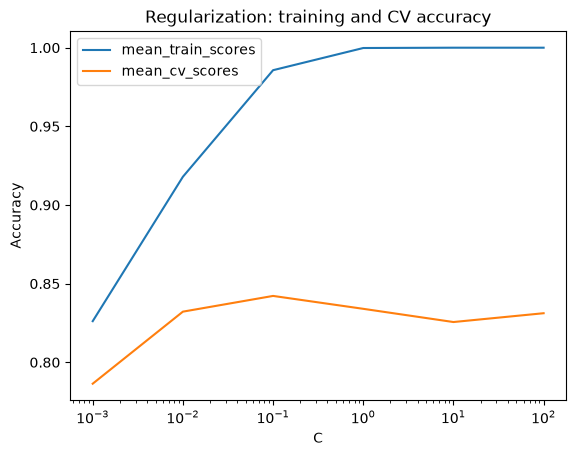

In [16]:
optimized_C = results_df.loc[results_df["mean_cv_scores"].idxmax(), "C"]
print(
    f"Best mean CV accuracy: {results_df['mean_cv_scores'].max():.3f}; "
    f"C = {optimized_C:g}"
)

results_df.plot(
    x="C", y=["mean_train_scores", "mean_cv_scores"], logx=True,
    ylabel="Accuracy", title="Regularization: training and CV accuracy",
)
plt.show()

In [17]:
pipe_lr = make_pipeline(
    CountVectorizer(max_features=10_000, stop_words="english"),
    LogisticRegression(max_iter=1000, C=optimized_C),
)
pipe_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('countvectorizer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['negative','positive']"
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


## Interpret learned coefficients

Select `C` using mean validation accuracy, then refit on all training reviews. The original run selected `C=0.1` with mean CV accuracy about 84.2%. Strong regularization can underfit; weak regularization can give nearly perfect training accuracy without improving validation accuracy. Read the current table and curve rather than assuming the same value always wins.

The classifier's `coef_` contains the learned word weights. In binary logistic regression, positive weights support `classes_[1]`, which here is `positive`; negative weights support `negative`.

In [18]:
feature_names = pipe_lr.named_steps["countvectorizer"].get_feature_names_out()
classifier = pipe_lr.named_steps["logisticregression"]
coeffs = classifier.coef_.ravel()
classifier.classes_

array(['negative', 'positive'], dtype=object)

In [19]:
word_coeff_df = pd.DataFrame(coeffs, index=feature_names, columns=["Coefficient"])
word_coeff_df

,Coefficient
00,0.058621
000,0.075009
007,0.005351
10,0.184220
100,-0.067604
...,...
zone,0.000927
zoo,-0.069953
zorro,0.041716
zu,0.072167


Sort the weights to find words that most strongly support each class, per occurrence. Holding other counts fixed, a positive coefficient increases the score for positive sentiment; a negative coefficient decreases it. These are associations learned from reviews, not causal effects or universal meanings of words.

In [20]:
word_coeff_df.sort_values(by="Coefficient", ascending=False)

,Coefficient
excellent,0.794894
amazing,0.622091
perfect,0.608633
wonderful,0.571676
great,0.535896
...,...
waste,-0.683588
terrible,-0.719606
boring,-0.725668
awful,-0.872302


In the original run, words such as “excellent” and “wonderful” supported positive sentiment, while “worst” and “awful” supported negative sentiment. Check whether the current rankings match that pattern. Some words may look surprising because their weights depend on the training reviews and other features.

The plot shows the 20 most positive and 20 most negative weights. Weight magnitude measures the change in the linear score per word occurrence; it is not itself a probability change.

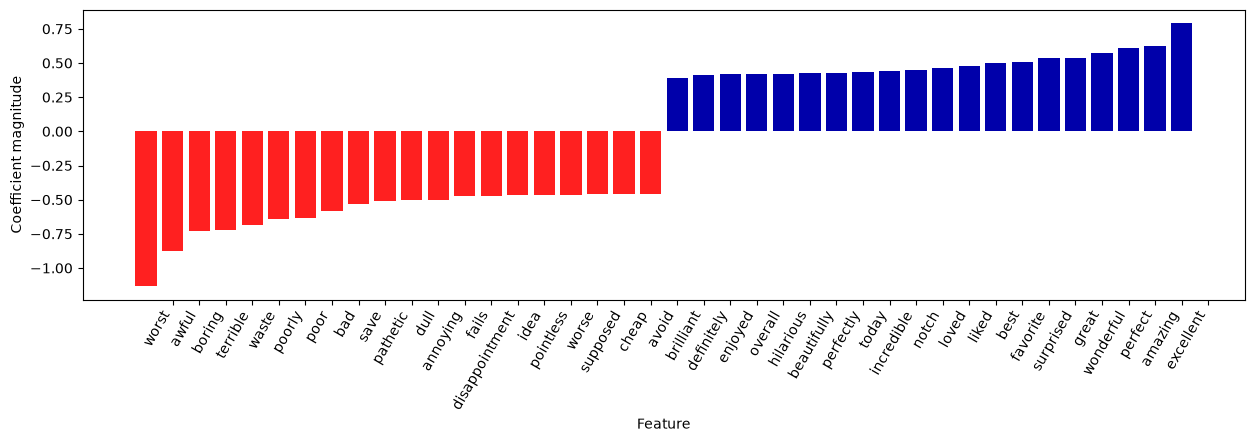

In [21]:
mglearn.tools.visualize_coefficients(coeffs, feature_names, n_top_features=20)

## Explain individual predictions

These two invented reviews contain mixed sentiment and sarcasm. Before running the next cells, predict the labels and identify words you think will influence the model.

In [22]:
fake_reviews = ["It got a bit boring at times but the direction was excellent and the acting was flawless. Overall I enjoyed the movie and I highly recommend it!",
 "The plot was shallower than a kiddie pool in a drought, but hey, at least we now know emojis should stick to texting and avoid the big screen."
]
fake_reviews

['It got a bit boring at times but the direction was excellent and the acting was flawless. Overall I enjoyed the movie and I highly recommend it!',
 'The plot was shallower than a kiddie pool in a drought, but hey, at least we now know emojis should stick to texting and avoid the big screen.']

### Labels and probabilities

Compare predicted labels with the probability table. Column names come from `classes_`, so each probability is explicitly associated with its label. A high predicted probability is the model's estimate, not a guarantee that it understood the review.

In [23]:
pipe_lr.predict(fake_reviews)

array(['positive', 'negative'], dtype=object)

In [24]:
pd.DataFrame(
    pipe_lr.predict_proba(fake_reviews),
    columns=pipe_lr.classes_,
    index=pd.Index(range(len(fake_reviews)), name="review"),
)

,negative,positive
review,,
0,0.173340,0.826660
1,0.688222,0.311778


In [25]:
pipe_lr.classes_

array(['negative', 'positive'], dtype=object)

### Word contributions

The first review combines “boring” with positive language; the second expresses criticism indirectly. Bag-of-words cannot reliably understand sarcasm or phrases such as “not excellent.” English stop-word removal can also remove negation words.

For each review, calculate **word count × coefficient**. Summing these contributions and the intercept gives the linear score (log-odds for positive sentiment). Applying the sigmoid function gives the positive-class probability. The table and plot below show contributions, rather than just the weights of words that occur.

In [26]:
def plot_coeff_example(model, review, coeffs, feature_names, n_top_feats=6):
    """Show word counts, weights, and contributions to a review's score."""
    print(review)
    counts = model.named_steps["countvectorizer"].transform([review]).toarray().ravel()
    present = counts > 0
    contributions = counts[present] * coeffs[present]
    ex_df = pd.DataFrame(
        {
            "Count": counts[present],
            "Coefficient": coeffs[present],
            "Contribution": contributions,
        },
        index=np.asarray(feature_names)[present],
    )
    intercept = model.named_steps["logisticregression"].intercept_[0]
    score = intercept + contributions.sum()
    print(f"Intercept: {intercept:.3f}; linear score: {score:.3f}")
    print(f"Positive-class probability: {model.predict_proba([review])[0, 1]:.4f}")

    if present.any():
        selected = ex_df.reindex(
            ex_df["Contribution"].abs().nlargest(2 * n_top_feats).index
        ).sort_values("Contribution")
        selected["Contribution"].plot.barh(
            color=["tab:blue" if value > 0 else "tab:red"
                   for value in selected["Contribution"]],
            figsize=(9, 5), title="Largest word contributions",
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.xlabel("Word count × coefficient")
        plt.tight_layout()
        plt.show()
    else:
        print("No vocabulary words found; the intercept determines the score.")
    return ex_df.sort_values("Contribution", ascending=False)

It got a bit boring at times but the direction was excellent and the acting was flawless. Overall I enjoyed the movie and I highly recommend it!
Intercept: -0.009; linear score: 1.562
Positive-class probability: 0.8267


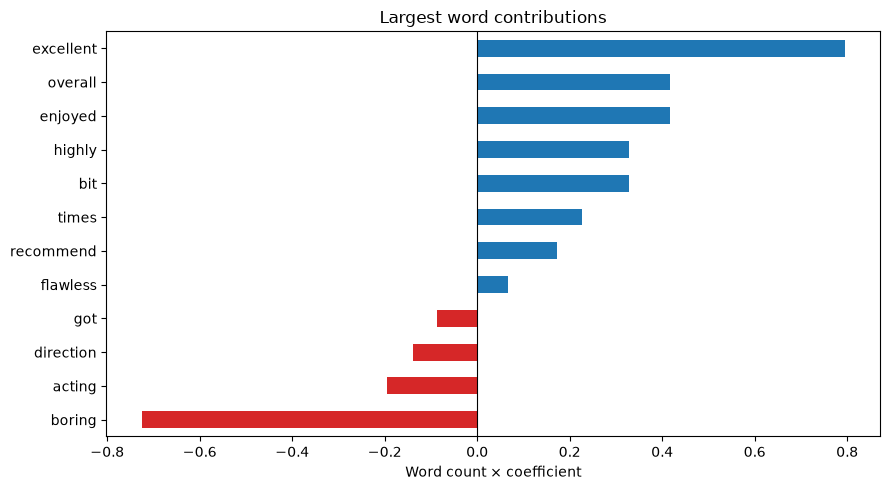

,Count,Coefficient,Contribution
excellent,1,0.794894,0.794894
overall,1,0.417289,0.417289
enjoyed,1,0.416470,0.416470
highly,1,0.328111,0.328111
bit,1,0.327412,0.327412
times,1,0.227090,0.227090
recommend,1,0.172985,0.172985
flawless,1,0.066854,0.066854
movie,1,-0.033348,-0.033348
got,1,-0.087397,-0.087397


In [27]:
plot_coeff_example(pipe_lr, fake_reviews[0], coeffs, feature_names)

The plot was shallower than a kiddie pool in a drought, but hey, at least we now know emojis should stick to texting and avoid the big screen.
Intercept: -0.009; linear score: -0.792
Positive-class probability: 0.3118


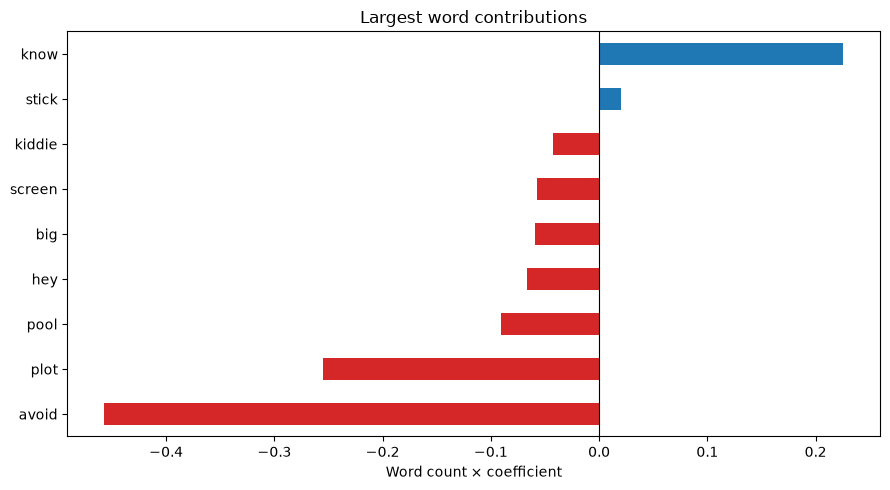

,Count,Coefficient,Contribution
know,1,0.225363,0.225363
stick,1,0.020377,0.020377
kiddie,1,-0.042543,-0.042543
screen,1,-0.057418,-0.057418
big,1,-0.059373,-0.059373
hey,1,-0.066556,-0.066556
pool,1,-0.090659,-0.090659
plot,1,-0.254875,-0.254875
avoid,1,-0.457039,-0.457039


In [28]:
plot_coeff_example(pipe_lr, fake_reviews[1], coeffs, feature_names)

## Inspect extreme training predictions

### Highest probability of positive sentiment

Find training reviews with the highest predicted probability for each class. These are examples the fitted model has already seen, so they illustrate its behavior rather than establish performance on unseen reviews. Extreme probabilities need not be well calibrated or correct.

In [29]:
train_probs = pipe_lr.predict_proba(X_train)
pos_class_idx = np.flatnonzero(pipe_lr.classes_ == "positive")[0]
neg_class_idx = np.flatnonzero(pipe_lr.classes_ == "negative")[0]
pos_probs = train_probs[:, pos_class_idx]
pos_probs

array([0.97581663, 0.27576982, 0.93402132, ..., 0.75329946, 0.87516818,
       0.00630932], shape=(5000,))

`argmax` returns the position of the highest positive-class probability. Use `.iloc` to retrieve the matching review, because dataframe index labels were retained during splitting.

In [30]:
most_positive_id = np.argmax(pos_probs)

In [31]:
print(f"True target: {y_train.iloc[most_positive_id]}")
print(f"Predicted target: {pipe_lr.predict(X_train.iloc[[most_positive_id]])[0]}")
print(f"Positive-class probability: {pos_probs[most_positive_id]:.4f}")

True target: positive
Predicted target: positive
Positive-class probability: 1.0000


Inspect the contributions and intercept. Does the resulting score explain why this review receives a high positive-class probability?

This is an awesome Amicus horror anthology, with 3 great stories, and fantastic performances!, only the last story disappoints. All the characters are awesome, and the film is quite chilling and suspenseful, plus Peter Cushing and Christopher Lee are simply amazing in this!. It's very underrated and my favorite story has to be the 3rd one "Sweets To The Sweet", plus all the characters are very likable. Some of it's predictable, and the last story was incredibly disappointing and rather bland!, however the ending was really cool!. This is an awesome Amicus horror anthology, with 3 great stories, and fantastic performances, only the last story disappoints!, i say it's must see!.  1st Story ("Method for Murder"). This is an awesome story, with plenty of suspense, and the killer Dominic is really creepy, and it's very well acted as well!. This was the perfect way to start off with a story, and for the most part it's unpredictable, plus the double twist ending is shocking, and quite creepy!

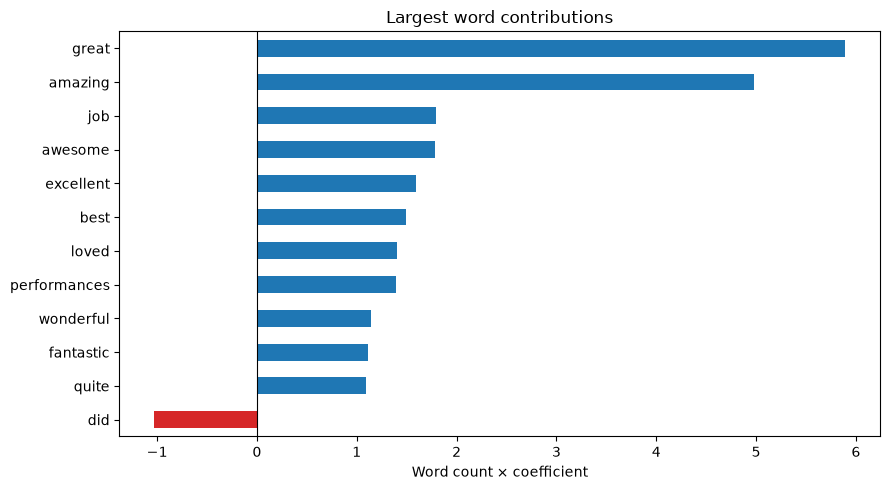

,Count,Coefficient,Contribution
great,11,0.535896,5.894854
amazing,8,0.622091,4.976729
job,5,0.359078,1.795392
awesome,6,0.297706,1.786236
excellent,2,0.794894,1.589788
...,...,...,...
predictable,2,-0.318434,-0.636868
bland,2,-0.338324,-0.676648
terrible,1,-0.719606,-0.719606
ending,5,-0.147757,-0.738785


In [32]:
plot_coeff_example(pipe_lr, X_train.iloc[most_positive_id], coeffs, feature_names)

A positive total score supports positive sentiment. Counts matter: a word with a modest coefficient can contribute substantially if it occurs many times. The most influential words alone do not give the full score; every vocabulary word present and the intercept contribute.

### Highest probability of negative sentiment

In [33]:
neg_probs = train_probs[:, neg_class_idx]
neg_probs

array([0.02418337, 0.72423018, 0.06597868, ..., 0.24670054, 0.12483182,
       0.99369068], shape=(5000,))

In [34]:
most_negative_id = np.argmax(neg_probs)

In [35]:
print(f"True target: {y_train.iloc[most_negative_id]}")
print(f"Predicted target: {pipe_lr.predict(X_train.iloc[[most_negative_id]])[0]}")
print(f"Negative-class probability: {neg_probs[most_negative_id]:.4f}")

True target: negative
Predicted target: negative
Negative-class probability: 1.0000


Zombi 3 starts as a group of heavily armed men steal a experimental chemical developed to reanimate the dead, while trying to escape the man is shot at & the metal container holding the chemical is breached. The man gets some of the green chemical on a wound on his hand which soon after turns him into a flesh eating cannibalistic zombie. Within hours the surrounding area is crawling with the flesh easting undead on the look out for fresh victims, Kenny (Deran Sarafian) & his army buddies find themselves in big trouble as they stop to help Patricia (Beatrice Ring) & her friend Lia (Deborah Bergammi) who has been pecked by zombie birds (!). General Morton is in charge of the situation & has to stop the zombie plague from spread throughout the whole world! But will he & his men succeed?  This Italian produced film was to be directed by Italian zombie gore film auteur Lucio Fulci but the story goes he suffered a stroke & therefore couldn't finish the film so producer Franco Gaudenzi asked 

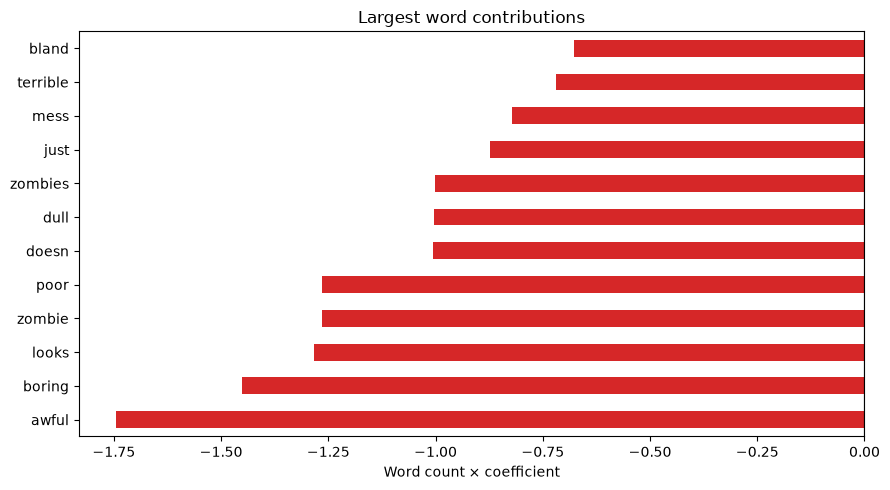

,Count,Coefficient,Contribution
look,3,0.220629,0.661887
gore,6,0.094537,0.567221
fulci,4,0.112682,0.450729
man,2,0.206841,0.413682
fun,1,0.387537,0.387537
...,...,...,...
poor,2,-0.632143,-1.264286
zombie,8,-0.158068,-1.264548
looks,4,-0.320611,-1.282445
boring,2,-0.725668,-1.451336


In [36]:
plot_coeff_example(pipe_lr, X_train.iloc[most_negative_id], coeffs, feature_names)

A negative total score supports negative sentiment. Compare the review's actual label with the prediction and examine which word contributions explain the result. A convincing explanation of the model's arithmetic does not establish that its reading of the review is correct.

## Takeaways and questions

We improved on a majority-class baseline, selected regularization using cross-validation, and connected predictions to word counts, coefficients, and an intercept. The test set remains reserved; a final evaluation would follow only after model choices are settled.

- Why must the vectorizer be inside the cross-validation pipeline?
- Why can a smaller `C` reduce training accuracy while improving validation accuracy?
- How do a word's coefficient and its contribution to a particular review differ?
- What can this model miss in a sarcastic review or a negated phrase?
- Can we identify influential features with k-NN or decision trees? How would those explanations differ from linear coefficients?